# Day 1: Super-resolution e Deconvoluzione

In questo notebook esploreremo il problema della ricostruzione di immagini degradate da sfocatura (blur) e rumore. Il modello matematico di riferimento è un sistema lineare:

$$
y = A x + n
$$

Dove:
- $y$: Immagine misurata (sfocata e rumorosa)
- $x$: Immagine "vera" (che vogliamo recuperare)
- $A$: Operatore lineare (convoluzione con una PSF - Point Spread Function)
- $n$: Rumore additivo (assunto Gaussiano e non correlato)

## Setup e Librerie
Importiamo le librerie necessarie.  
Useremo `scikit-image` per le immagini di test, `scipy.ndimage` per la convoluzione e `numpy` per algebra lineare e FFT.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data, color
from numpy.fft import fft2, ifft2, fftshift, ifftshift

# Funzione di utilità per visualizzare le immagini
def show_images(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()

## 1. Creazione/Caricamento immagine di test
Usiamo l'immagine "camera" (cameraman) di scikit-image, convertita in float [0,1].

Dimensioni immagine: (512, 512)


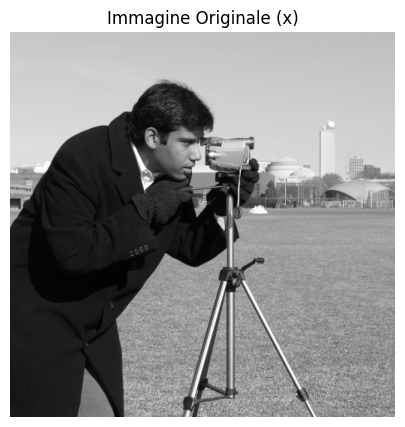

In [24]:
original_image = data.camera().astype(float)/255.0
# Se preferisci l'astronauta:
# original_image = color.rgb2gray(data.astronaut())

print(f"Dimensioni immagine: {original_image.shape}")
show_images([original_image], ["Immagine Originale (x)"])

## Esperimento 1: Inversione Diretta nello Spazio di Fourier

Se trascuriamo il rumore ($n=0$), il sistema diventa $y = Ax$. Se $A$ è una convoluzione con un kernel $h$ (PSF), per il teorema di convoluzione:

$$
F(y) = F(h) \cdot F(x) \quad \Rightarrow \quad \hat{x} = F^{-1}\left( \frac{F(y)}{F(h)} \right)
$$

### 1.1 Creazione della PSF e Sfocatura

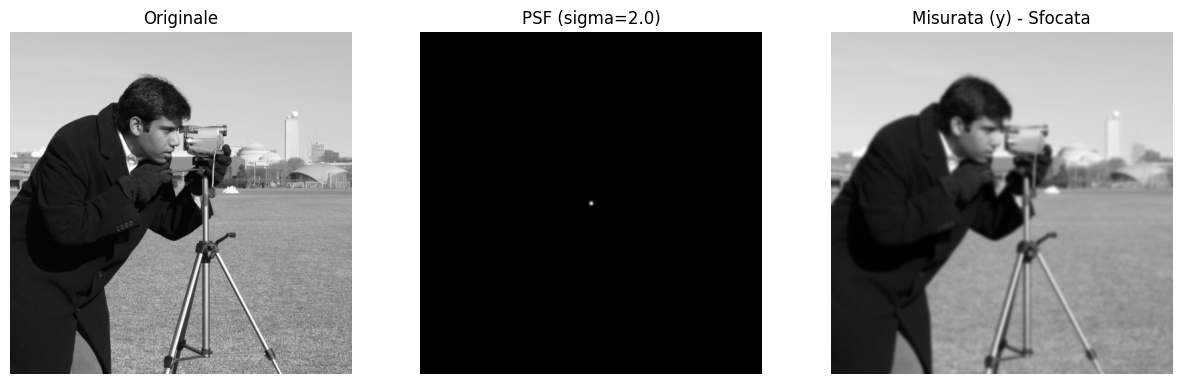

In [25]:
def create_psf(shape, sigma):
    """Crea una PSF Gaussiana centrata nello spazio di Fourier."""
    impulse = np.zeros(shape)
    center = (shape[0]//2, shape[1]//2)
    impulse[center] = 1.0
    psf = ndimage.gaussian_filter(impulse, sigma=sigma)
    return psf

SIGMA = 2.0  # Modifica tra 0.5 e 3.0

psf_spatial = create_psf(original_image.shape, SIGMA)
blurred_image = ndimage.gaussian_filter(original_image, sigma=SIGMA)

show_images([original_image, psf_spatial, blurred_image],
            ["Originale", f"PSF (sigma={SIGMA})", "Misurata (y) - Sfocata"])

### 1.2 Deconvoluzione Diretta (Inverse Filtering)

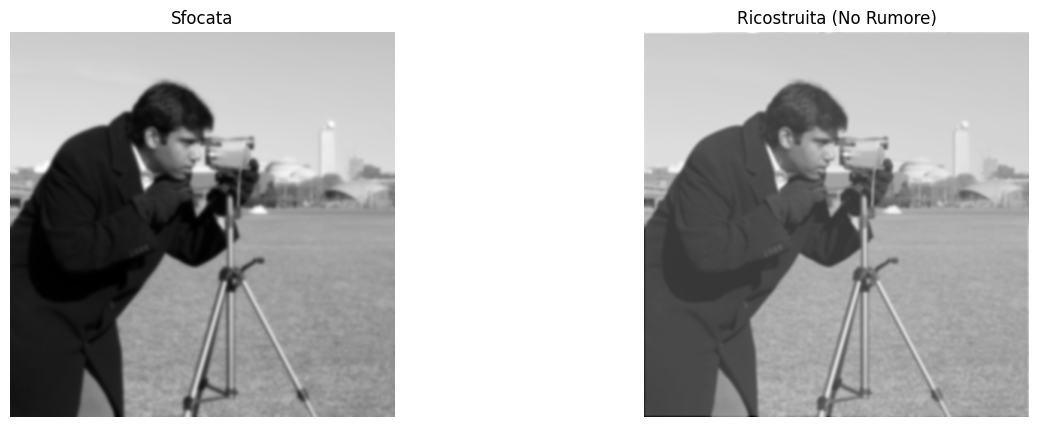

In [26]:
def inverse_filter(blurred_img, psf, epsilon=10e-1):
    """
    Esegue la deconvoluzione nel dominio delle frequenze.
    epsilon serve per evitare divisioni per zero.
    """
    Y = fft2(blurred_img)
    H = fft2(ifftshift(psf))
    H_inv = 1.0 / (H + epsilon)
    X_hat_freq = Y * H_inv
    x_hat = np.real(ifft2(X_hat_freq))
    return x_hat

reconstructed_ideal = inverse_filter(blurred_image, psf_spatial)
show_images([blurred_image, reconstructed_ideal],
            ["Sfocata", "Ricostruita (No Rumore)"])

### 1.b Effetto del Rumore
Aggiungiamo rumore gaussiano all'immagine sfocata.

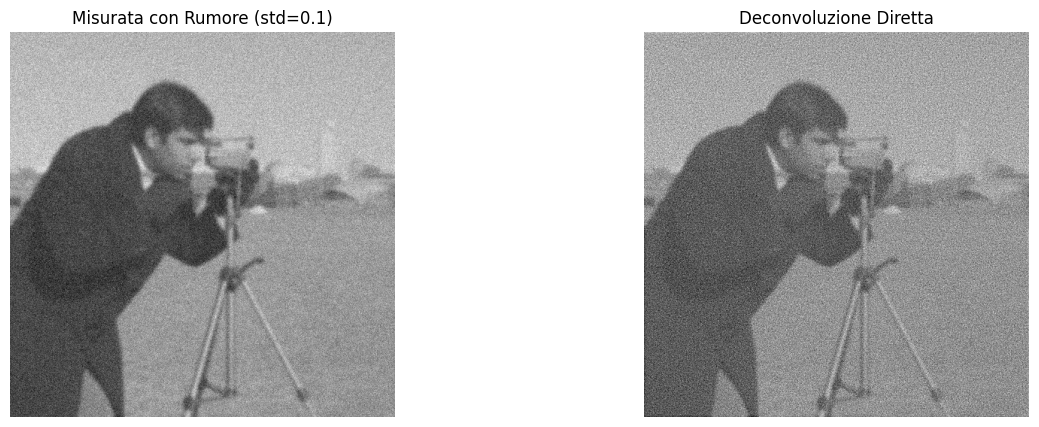

In [27]:
noise_sigma = 0.1
noise = np.random.normal(0, noise_sigma, blurred_image.shape)
y_noisy = blurred_image + noise

reconstructed_noisy = inverse_filter(y_noisy, psf_spatial)
show_images([y_noisy, reconstructed_noisy],
            [f"Misurata con Rumore (std={noise_sigma})", "Deconvoluzione Diretta"])

### 1.c Filtro Inverso Regolarizzato (Wiener-like)

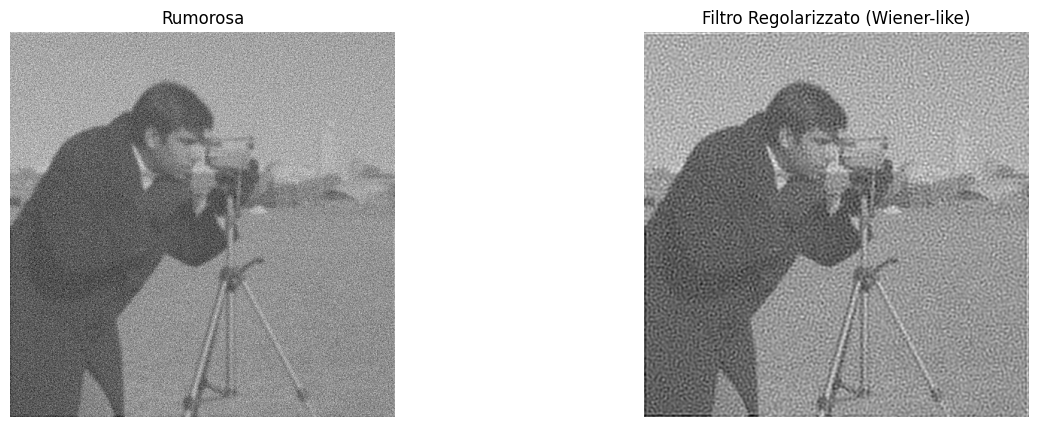

In [28]:
def regularized_inverse_filter(blurred_img, psf, K=0.01):
    Y = fft2(blurred_img)
    H = fft2(ifftshift(psf))
    X_hat_freq = (Y * np.conj(H)) / (np.abs(H)**2 + K)
    x_hat = np.real(ifft2(X_hat_freq))
    return x_hat

reconstructed_regularized = regularized_inverse_filter(y_noisy, psf_spatial, K=0.01)
show_images([reconstructed_noisy, reconstructed_regularized],
            ["Rumorosa", "Filtro Regolarizzato (Wiener-like)"]) #mmh, si puo fare di meglio!

### 1.d Deconvoluzione con PSF Errata

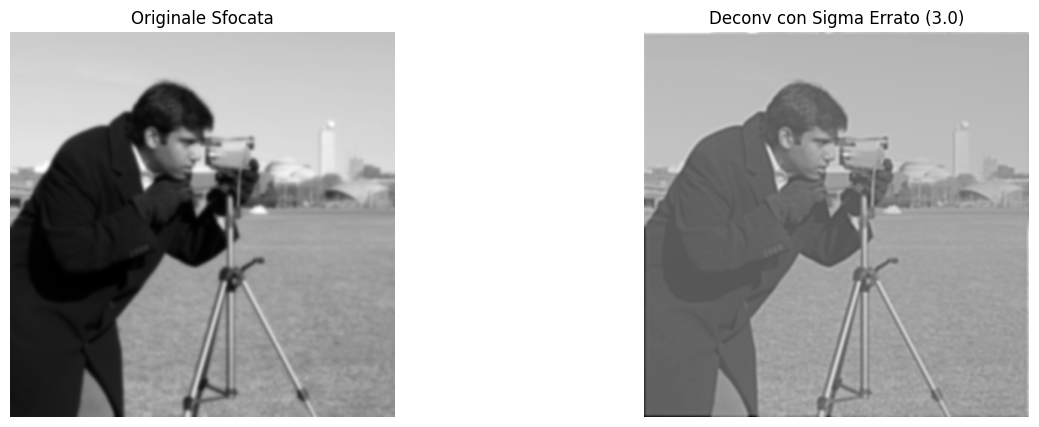

In [29]:
wrong_sigma = SIGMA * 1.5
psf_wrong = create_psf(original_image.shape, wrong_sigma)
reconstructed_wrong_psf = inverse_filter(blurred_image, psf_wrong, epsilon=5e-1)

show_images([blurred_image, reconstructed_wrong_psf],
            ["Originale Sfocata", f"Deconv con Sigma Errato ({wrong_sigma})"])

## Esperimento 2: Ricostruzione Iterativa (Gradient Descent)
Minimizzazione del Least Squares:

$$
L(x) = \frac{1}{2} \|Ax - y\|^2
$$

Aggiornamento iterativo:

$$
x^{k+1} = x^k + \alpha A^T (y - Ax^k)
$$

In [30]:
class IterativeDeblur:
    def __init__(self, psf_sigma):
        self.sigma = psf_sigma
        
    def A(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def AT(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def solve(self, y, iterations=50, x_init=None, verbose=True):
        if x_init is None:
            x = np.zeros_like(y)
        else:
            x = x_init.copy()
        history = []
        for i in range(iterations):
            Ax = self.A(x)
            residual = y - Ax
            g = self.AT(residual)
            Ag = self.A(g)
            norm_g_sq = np.sum(g**2)
            norm_Ag_sq = np.sum(Ag**2)
            if norm_Ag_sq < 1e-10:
                break
            alpha = norm_g_sq / norm_Ag_sq
            x = x + alpha * g
            update_norm = np.linalg.norm(alpha * g)
            history.append(update_norm)
            if verbose and i % 10 == 0:
                print(f"Iter {i}: Step Norm = {update_norm:.5f}")
        return x, history

solver = IterativeDeblur(psf_sigma=SIGMA)

### 2.1 Test di Convergenza e Inizializzazione

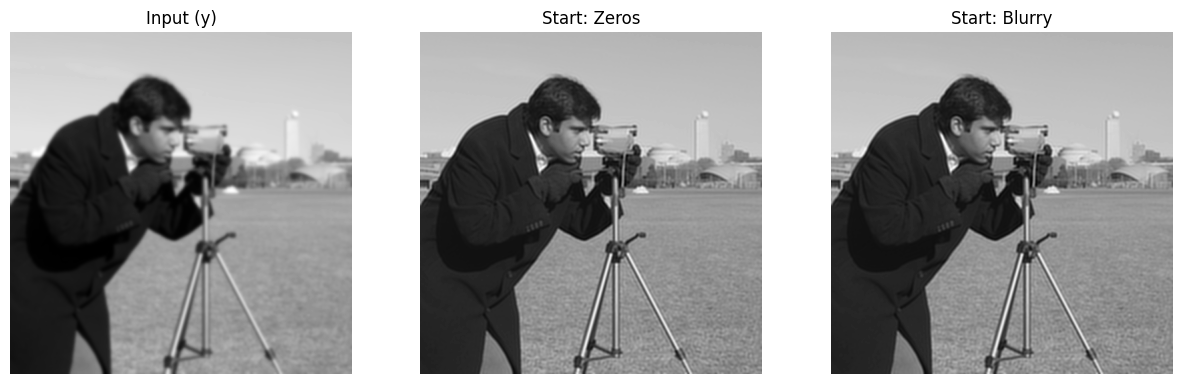

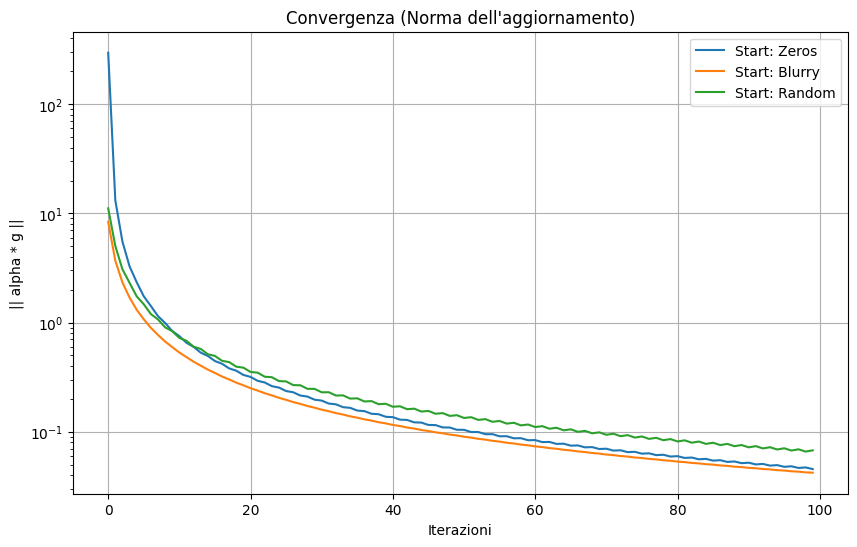

In [31]:
x_rec_zeros, hist_zeros = solver.solve(blurred_image, iterations=100, x_init=np.zeros_like(blurred_image), verbose=False)
x_rec_blur, hist_blur = solver.solve(blurred_image, iterations=100, x_init=blurred_image, verbose=False)
random_init = blurred_image + np.random.normal(0,0.1,blurred_image.shape)
x_rec_rand, hist_rand = solver.solve(blurred_image, iterations=100, x_init=random_init, verbose=False)

show_images([blurred_image, x_rec_zeros, x_rec_blur],
            ["Input (y)", "Start: Zeros", "Start: Blurry"])

plt.figure(figsize=(10,6))
plt.plot(hist_zeros, label='Start: Zeros')
plt.plot(hist_blur, label='Start: Blurry')
plt.plot(hist_rand, label='Start: Random')
plt.yscale('log')
plt.title('Convergenza (Norma dell\'aggiornamento)')
plt.xlabel('Iterazioni')
plt.ylabel('|| alpha * g ||')
plt.legend()
plt.grid(True)
plt.show()

### 2.2 Test su Immagine Rumorosa

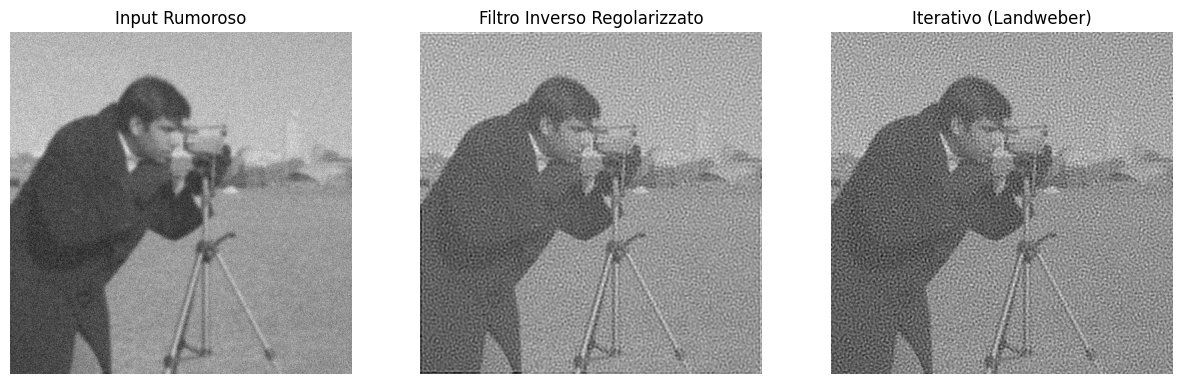

In [32]:
x_rec_noisy_iter, hist_noisy = solver.solve(y_noisy, iterations=50, x_init=y_noisy, verbose=False)
show_images([y_noisy, reconstructed_regularized, x_rec_noisy_iter],
            ["Input Rumoroso", "Filtro Inverso Regolarizzato", "Iterativo (Landweber)"])

### 2.3 Stabilità dell'inizializzazione con Rumore

Distanza euclidea tra le due soluzioni dopo 50 iterazioni: 481.6557


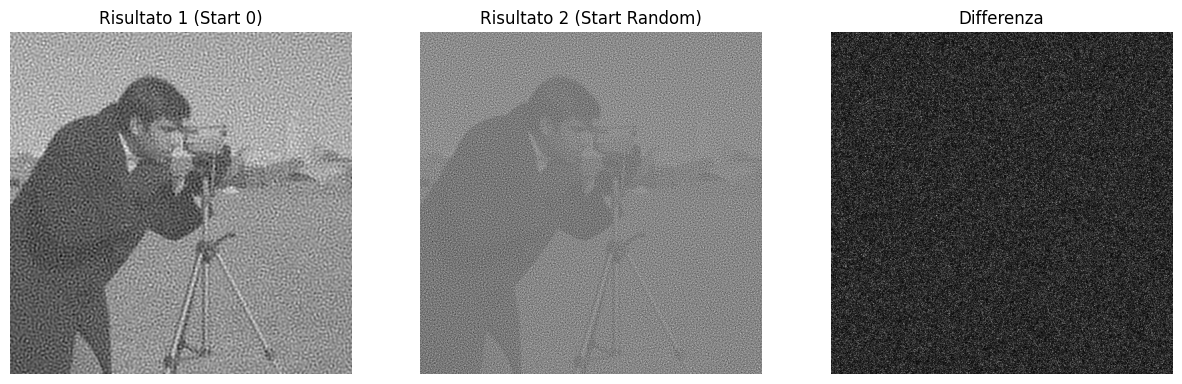

In [33]:
res1, _ = solver.solve(y_noisy, iterations=50, x_init=np.zeros_like(y_noisy), verbose=False)
rand_start = np.random.normal(0,1,y_noisy.shape)
res2, _ = solver.solve(y_noisy, iterations=50, x_init=rand_start, verbose=False)
diff_norm = np.linalg.norm(res1 - res2)
print(f"Distanza euclidea tra le due soluzioni dopo 50 iterazioni: {diff_norm:.4f}")

show_images([res1, res2, np.abs(res1-res2)],
            ["Risultato 1 (Start 0)", "Risultato 2 (Start Random)", "Differenza"])

##GUARDA:##

https://scikit-image.org/docs/stable/auto_examples/filters/plot_dog.html

https://scikit-image.org/docs/stable/auto_examples/filters/plot_deconvolution.html

https://github.com/PyTomography/PyTomography/tree/main

PARTE IN PIU: 

## Parte 3: Gradient Ascent e MLEM

Mentre il metodo dei minimi quadrati (Least Squares) visto prima assume che il rumore sia Gaussiano (e quindi minimizza la norma L2 $\|Ax-y\|^2$), in molte applicazioni reali (come la conta dei fotoni) il rumore segue una statistica di Poisson.

In questo caso, l'obiettivo è massimizzare la Log-Likelihood (verosimiglianza).

### 3.1 Gradient Ascent (Salita del Gradiente)

Vogliamo massimizzare la funzione di Log-Likelihood $L(x)$. L'aggiornamento iterativo è dato da:

$$
x^{(k+1)} = x^{(k)} + \alpha \cdot \nabla L(x^{(k)})
$$

Dove il gradiente della Log-Likelihood per rumore di Poisson è:

$$
\nabla L(x) = A^T \left( \frac{y}{Ax} - 1 \right)
$$

(Nota: la divisione y/Ax e le operazioni sono element-wise).

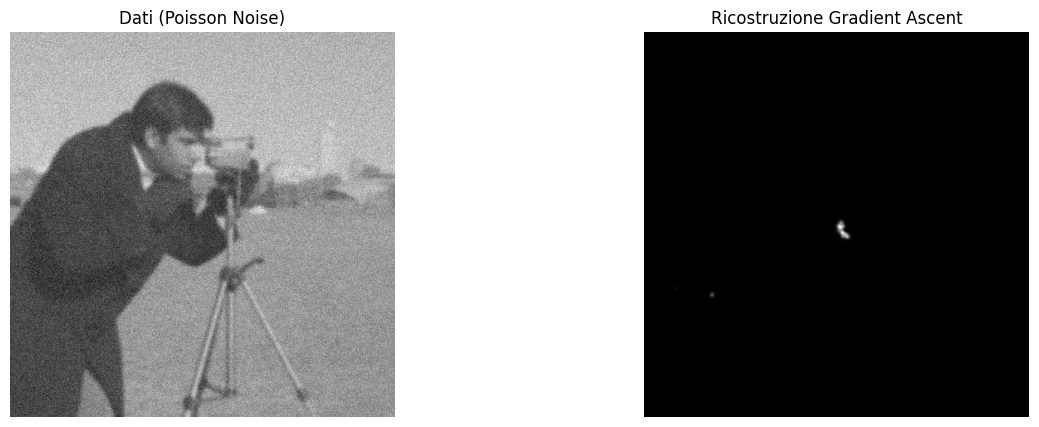

In [34]:
class GradientAscentPoisson:
    def __init__(self, psf_sigma):
        self.sigma = psf_sigma
        
    def A(self, x):
        # Convoluzione (Forward projection)
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def AT(self, x):
        # Correlazione (Back projection) - per gaussiana simmetrica è uguale ad A
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def solve(self, y, iterations=50, alpha=0.1, x_init=None):
        """
        Gradient Ascent per massimizzare la Poisson Log-Likelihood.
        y: dati misurati (con rumore)
        alpha: step size (fisso o adattivo)
        """
        # Inizializzazione: NON può essere zero per MLEM/Poisson (log(0) = -inf)
        # Si usa spesso un'immagine uniforme o l'immagine stessa.
        if x_init is None:
            x = np.ones_like(y) * np.mean(y) 
        else:
            x = x_init.copy()
            # Assicuriamo che non ci siano zeri o valori negativi
            x[x <= 0] = 1e-6
            
        history = []
        
        for k in range(iterations):
            # 1. Forward Projection: Ax
            Ax = self.A(x)
            
            # Evitiamo divisioni per zero
            Ax[Ax < 1e-10] = 1e-10
            
            # 2. Calcolo del rapporto: y / Ax
            ratio = y / Ax
            
            # 3. Calcolo del termine residuo: (y/Ax) - 1
            residual_term = ratio - 1.0
            
            # 4. Backprojection del residuo: A^T * (y/Ax - 1)
            gradient = self.AT(residual_term)
            
            # 5. Aggiornamento (Salita)
            x_new = x + alpha * gradient
            
            # Constraint di non-negatività (fisica: non esistono fotoni negativi)
            x_new[x_new < 0] = 0
            x = x_new
            
            # Monitoraggio (opzionale: norma del gradiente)
            grad_norm = np.linalg.norm(gradient)
            history.append(grad_norm)
            
        return x, history

# Test del Gradient Ascent
solver_ga = GradientAscentPoisson(psf_sigma=SIGMA)

# Nota: alpha (step size) è critico qui. Se troppo alto diverge, troppo basso è lento.
# Per Poisson spesso servono alpha piccoli.
x_rec_ga, hist_ga = solver_ga.solve(y_noisy, iterations=50, alpha=0.5, x_init=np.ones_like(y_noisy))

show_images([y_noisy, x_rec_ga], ["Dati (Poisson Noise)", "Ricostruzione Gradient Ascent"])

### 3.2 MLEM (Maximum Likelihood Expectation Maximization)

L'algoritmo MLEM è lo standard de facto in PET e SPECT. È una forma specifica di Gradient Ascent dove il passo $\alpha$ non è costante, ma viene scelto in modo "intelligente" per garantire la non-negatività e la stabilità (è un algoritmo moltiplicativo).

La formula di aggiornamento è:

$$
x_j^{(k+1)} = \frac{x_j^{(k)}}{\sum_i A_{ij}} A^T \left( \frac{y}{Ax^{(k)}} \right)
$$

In notazione matriciale vettoriale (più facile da implementare):

$$
x^{(k+1)} = x^{(k)} \cdot \frac{A^T \left( \frac{y}{Ax^{(k)}} \right)}{A^T \mathbf{1}}
$$

Dove:

- $y/Ax^{(k)}$ è il rapporto tra misura reale e misura stimata.
- $A^T (…)$ è la retroproiezione di questo rapporto (Backprojection).
- $A^T \mathbf{1}$ è un termine di normalizzazione (immagine di sensibilità).

La moltiplicazione e divisione sono element-wise.

/var/folders/gj/gl2kb7qs563ckkg3vvvr7dvh0000gn/T/ipykernel_8223/4167682059.py:40: RuntimeWarning: overflow encountered in multiply
  x = x * (correction / sensitivity)
/var/folders/gj/gl2kb7qs563ckkg3vvvr7dvh0000gn/T/ipykernel_8223/4167682059.py:45: RuntimeWarning: invalid value encountered in subtract
  ll = np.sum(y * np.log(Ax) - Ax)


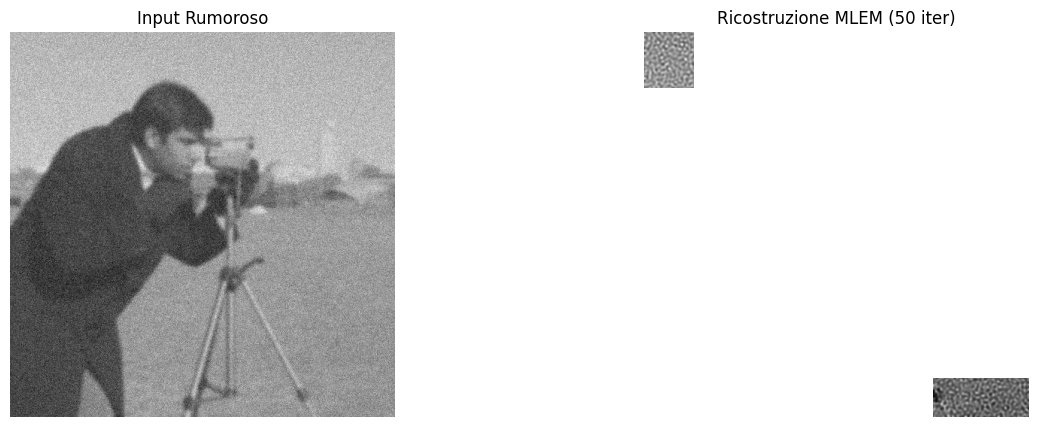

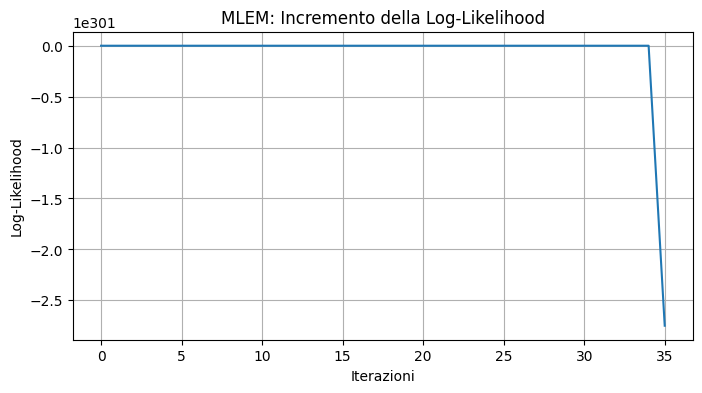

In [35]:
class MLEM:
    def __init__(self, psf_sigma):
        self.sigma = psf_sigma
        
    def A(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def AT(self, x):
        return ndimage.gaussian_filter(x, sigma=self.sigma)
    
    def solve(self, y, iterations=50, x_init=None):
        # Inizializzazione (Uniforme positiva)
        if x_init is None:
            x = np.ones_like(y)
        else:
            x = x_init.copy()
            x[x <= 0] = 1e-1 # Safety check
            
        # Calcolo immagine di sensibilità (Normalization map): A^T * 1
        # Nel caso di convoluzione con padding zero, i bordi hanno valori < 1
        ones_img = np.ones_like(y)
        sensitivity = self.AT(ones_img)
        # Evitiamo divisioni per zero nella sensibilità
        sensitivity[sensitivity < 1e-6] = 1.0 
        
        history = []
        
        for k in range(iterations):
            # 1. Forward Projection: y_est = Ax
            Ax = self.A(x)
            Ax[Ax < 1e-10] = 1e-10 # Stabilità
            
            # 2. Confronto (Rapporto): ratio = y / y_est
            ratio = y / Ax
            
            # 3. Backprojection del rapporto: correction = A^T * ratio
            correction = self.AT(ratio)
            
            # 4. Aggiornamento Moltiplicativo: x_new = x * correction / sensitivity
            x = x * (correction / sensitivity)
            
            # Monitoraggio: Likelihood o distanza
            # Qui usiamo la Log-Likelihood di Poisson (a meno di costanti)
            # L = sum( y * log(Ax) - Ax )
            ll = np.sum(y * np.log(Ax) - Ax)
            history.append(ll)
            
        return x, history

# Esecuzione MLEM
solver_mlem = MLEM(psf_sigma=SIGMA)

# Nota: MLEM non ha bisogno di 'alpha'. Converge da solo.
x_rec_mlem, hist_mlem = solver_mlem.solve(y_noisy, iterations=50)

show_images([y_noisy, x_rec_mlem], 
            ["Input Rumoroso", "Ricostruzione MLEM (50 iter)"])

# Confronto grafico della Log-Likelihood
plt.figure(figsize=(8,4))
plt.plot(hist_mlem)
plt.title("MLEM: Incremento della Log-Likelihood")
plt.xlabel("Iterazioni")
plt.ylabel("Log-Likelihood")
plt.grid()
plt.show()

## Confronto Finale e Risposte agli Esercizi

Qui uniamo i risultati per rispondere alle domande finali della traccia (Confronto inizializzazioni, effetto del rumore, convergenza).

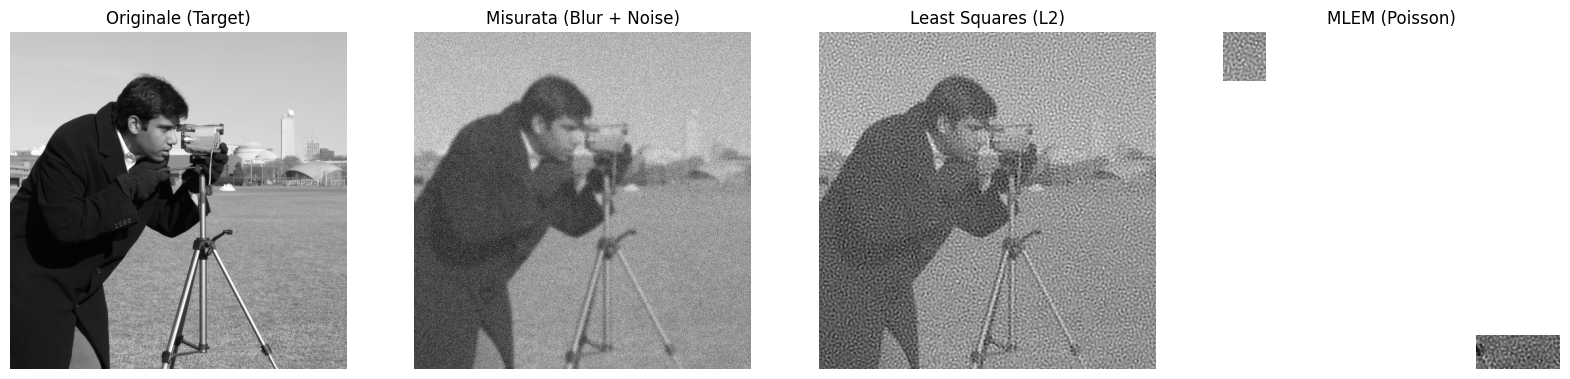

In [36]:
# Confronto visivo tra i metodi
# 1. Gradient Descent (Minimi Quadrati L2) - Ottimizzato per rumore Gaussiano
# 2. MLEM (Maximum Likelihood) - Ottimizzato per rumore Poisson (conteggi fotoni)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

# Originale
ax[0].imshow(original_image, cmap='gray')
ax[0].set_title("Originale (Target)")
ax[0].axis('off')

# Rumorosa
ax[1].imshow(y_noisy, cmap='gray')
ax[1].set_title("Misurata (Blur + Noise)")
ax[1].axis('off')

# Least Squares (Gradient Descent L2)
# Nota: usa il solver definito nell'Esperimento 2 (IterativeDeblur)
x_l2, _ = solver.solve(y_noisy, iterations=50, x_init=np.mean(y_noisy)*np.ones_like(y_noisy), verbose=False)
ax[2].imshow(x_l2, cmap='gray')
ax[2].set_title("Least Squares (L2)")
ax[2].axis('off')

# MLEM (Poisson)
ax[3].imshow(x_rec_mlem, cmap='gray')
ax[3].set_title("MLEM (Poisson)")
ax[3].axis('off')

plt.show()

### Spiegazione Teorica per l'esame

**Perché MLEM è spesso migliore in imaging medico?** 
Il Least Squares (L2) penalizza molto gli outlier quadratici e assume che il rumore sia costante su tutta l'immagine (o Gaussiano). In PET/Microscopia, dove ci sono pochi fotoni (zone scure), il rumore è basso, mentre dove è luminoso il rumore è alto (varianza = media in Poisson). MLEM incorpora questa informazione naturalmente: pesa meno gli errori nelle zone luminose e di più in quelle scure relative, rispettando la statistica dei dati.

**Vincolo di non-negatività:** 
Il Least Squares standard può produrre valori negativi nell'immagine (artefatti di "ringing" che scendono sotto zero), il che non ha senso fisico (non puoi avere intensità luminosa negativa). MLEM è un algoritmo moltiplicativo: se parti da un'immagine positiva ($x>0$) e i dati sono positivi ($y \geq 0$), l'immagine rimarrà sempre positiva.

**Convergenza e Rumore (Noise Fitting):** 
Anche MLEM soffre del problema del fitting del rumore. Se lo lasci girare per troppe iterazioni (es. 1000+), l'immagine diventerà "sgranata" (effetto checkerboard). Si vedranno punti molto luminosi isolati. Nelle prime iterazioni recupera i bordi (bassa/media frequenza), nelle ultime cerca di spiegare le fluttuazioni statistiche del rumore come se fossero dettagli reali. Soluzione: Fermarsi prima (Early stopping) o usare regolarizzazione (metodi MAP - Maximum A Posteriori).

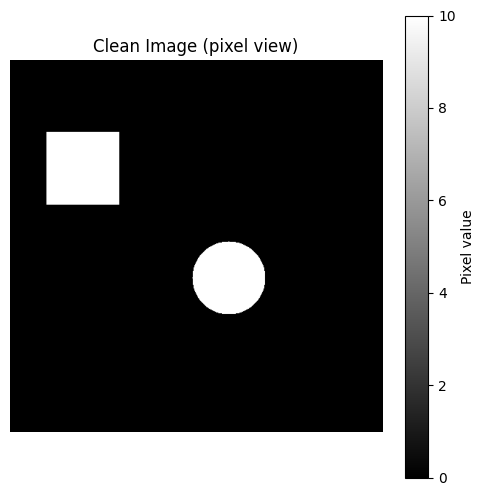

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

clean_image = np.zeros((512, 512))
unitary_matrix = np.zeros((100, 100))
unitary_matrix[:] = 10

for i in range(100, 200):
    for j in range(50, 150):
        clean_image[i, j] += unitary_matrix[i-100, j-50]
        
        
cx, cy = 300, 300   # centro del cerchio (spostato a destra)
r = 50              # raggio
value = 10

for i in range(cx - r, cx + r):
    for j in range(cy - r, cy + r):
        if (i - cx)**2 + (j - cy)**2 <= r**2:
            clean_image[i, j] += value


plt.figure(figsize=(6, 6))
plt.imshow(clean_image, cmap='gray')
plt.colorbar(label='Pixel value')
plt.title("Clean Image (pixel view)")
plt.axis('off')
plt.show()


## Parte 4: Analisi della Nuova Immagine Creata

Applichiamo la stessa analisi ai dati generati sinteticamente (clean_image), seguendo la struttura dei primi 3 esperimenti.

### 4.0 Preparazione e Normalizzazione


Dimensioni immagine sintetica: (512, 512)
Range immagine: Min=0.0000, Max=1.0000


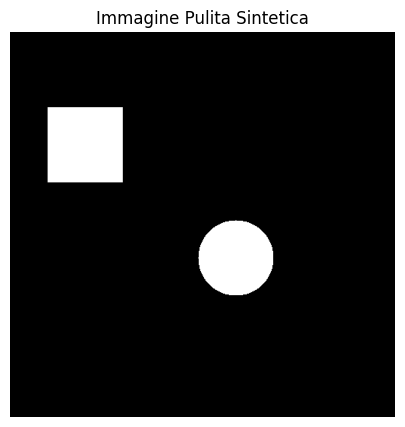

In [38]:
# Normalizzare l'immagine pulita per il range [0, 1]
clean_image_normalized = clean_image / np.max(clean_image)

print(f"Dimensioni immagine sintetica: {clean_image_normalized.shape}")
print(f"Range immagine: Min={clean_image_normalized.min():.4f}, Max={clean_image_normalized.max():.4f}")

show_images([clean_image_normalized], ["Immagine Pulita Sintetica"])


### 4.1 Creazione della PSF e Sfocatura

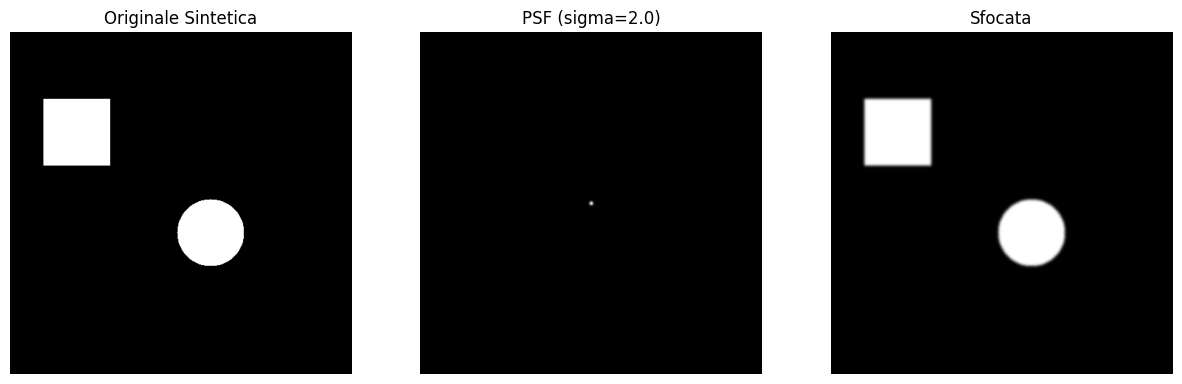

In [39]:
SIGMA_CLEAN = 2.0  # Stesso sigma del primo esperimento

psf_clean = create_psf(clean_image_normalized.shape, SIGMA_CLEAN)
blurred_clean = ndimage.gaussian_filter(clean_image_normalized, sigma=SIGMA_CLEAN)

show_images([clean_image_normalized, psf_clean, blurred_clean],
            ["Originale Sintetica", f"PSF (sigma={SIGMA_CLEAN})", "Sfocata"])


### 4.2 Deconvoluzione Diretta (Inverse Filtering)

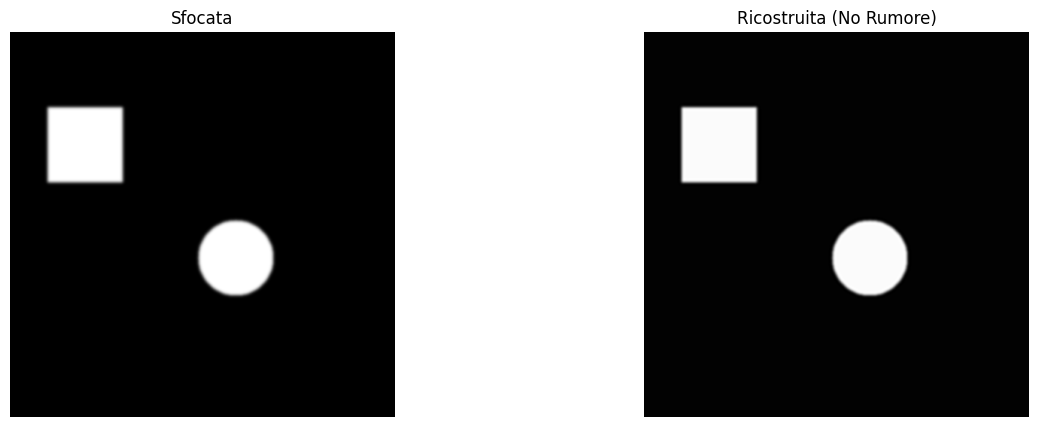

In [40]:
# Deconvoluzione diretta (ideale, senza rumore)
reconstructed_clean_ideal = inverse_filter(blurred_clean, psf_clean)

show_images([blurred_clean, reconstructed_clean_ideal],
            ["Sfocata", "Ricostruita (No Rumore)"])


### 4.3 Effetto del Rumore

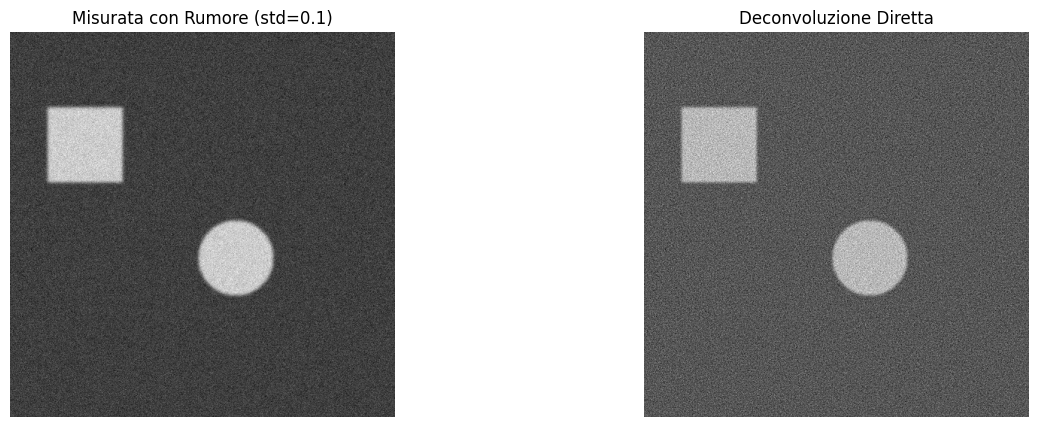

In [41]:
# Aggiungere rumore gaussiano all'immagine sfocata
noise_sigma_clean = 0.1
noise_clean = np.random.normal(0, noise_sigma_clean, blurred_clean.shape)
y_noisy_clean = blurred_clean + noise_clean

reconstructed_clean_noisy = inverse_filter(y_noisy_clean, psf_clean)

show_images([y_noisy_clean, reconstructed_clean_noisy],
            [f"Misurata con Rumore (std={noise_sigma_clean})", "Deconvoluzione Diretta"])


### 4.4 Filtro Inverso Regolarizzato (Wiener-like)

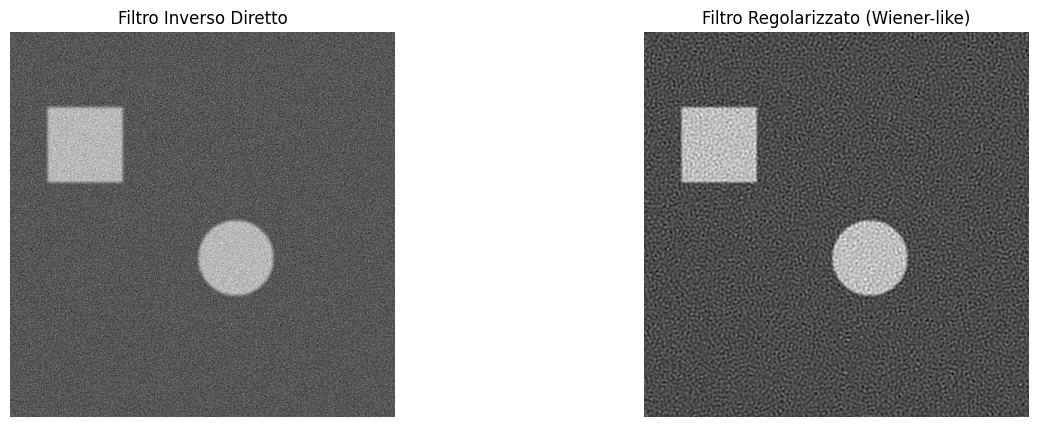

In [42]:
reconstructed_clean_regularized = regularized_inverse_filter(y_noisy_clean, psf_clean, K=0.01)

show_images([reconstructed_clean_noisy, reconstructed_clean_regularized],
            ["Filtro Inverso Diretto", "Filtro Regolarizzato (Wiener-like)"])

### 4.5 Ricostruzione Iterativa (Landweber) e Convergenza

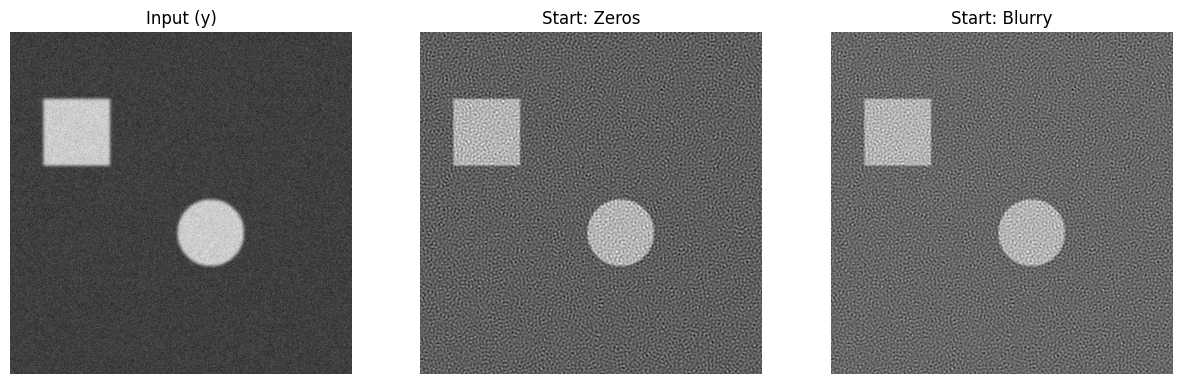

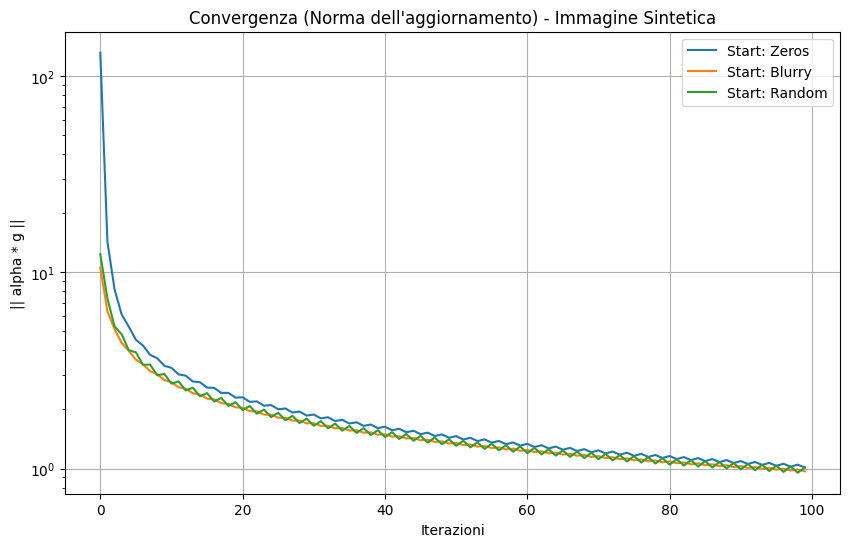

In [47]:
x_rec_clean_iter, hist_clean_iter = solver.solve(y_noisy_clean, iterations=100, x_init=np.zeros_like(y_noisy_clean), verbose=False)
x_rec_clean_blur, hist_clean_blur = solver.solve(y_noisy_clean, iterations=100, x_init=y_noisy_clean, verbose=False)
random_init_clean = y_noisy_clean + np.random.normal(0, 0.1, y_noisy_clean.shape)
x_rec_clean_rand, hist_clean_rand = solver.solve(y_noisy_clean, iterations=100, x_init=random_init_clean, verbose=False)

show_images([y_noisy_clean, x_rec_clean_iter, x_rec_clean_blur],
            ["Input (y)", "Start: Zeros", "Start: Blurry"])

plt.figure(figsize=(10, 6))
plt.plot(hist_clean_iter, label='Start: Zeros')
plt.plot(hist_clean_blur, label='Start: Blurry')
plt.plot(hist_clean_rand, label='Start: Random')
plt.yscale('log')
plt.title('Convergenza (Norma dell\'aggiornamento) - Immagine Sintetica')
plt.xlabel('Iterazioni')
plt.ylabel('|| alpha * g ||')
plt.legend()
plt.grid(True)
plt.show()

### 4.6 Test su Immagine Sintetica Rumorosa

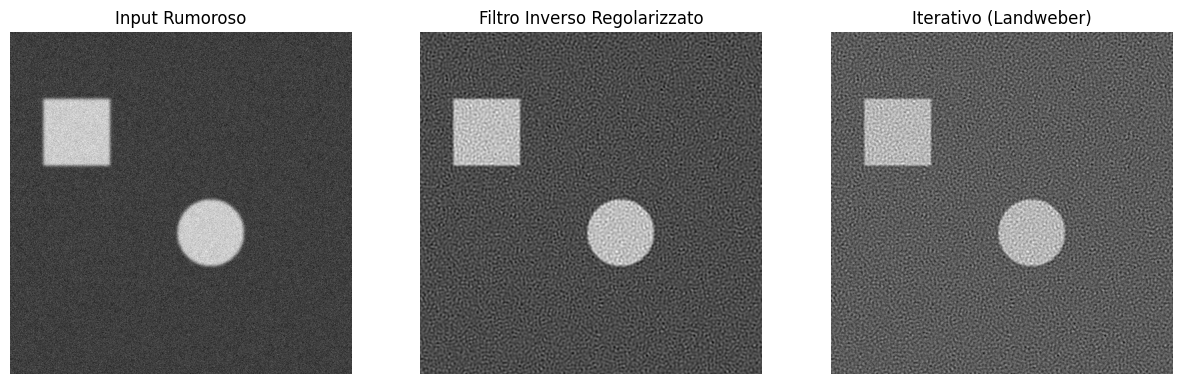

In [44]:
x_rec_clean_noisy_iter, hist_clean_noisy = solver.solve(y_noisy_clean, iterations=50, x_init=y_noisy_clean, verbose=False)
show_images([y_noisy_clean, reconstructed_clean_regularized, x_rec_clean_noisy_iter],
            ["Input Rumoroso", "Filtro Inverso Regolarizzato", "Iterativo (Landweber)"])

### 4.7 Stabilità dell'Inizializzazione su Immagine Sintetica

Distanza euclidea tra le due soluzioni dopo 50 iterazioni: 481.3749


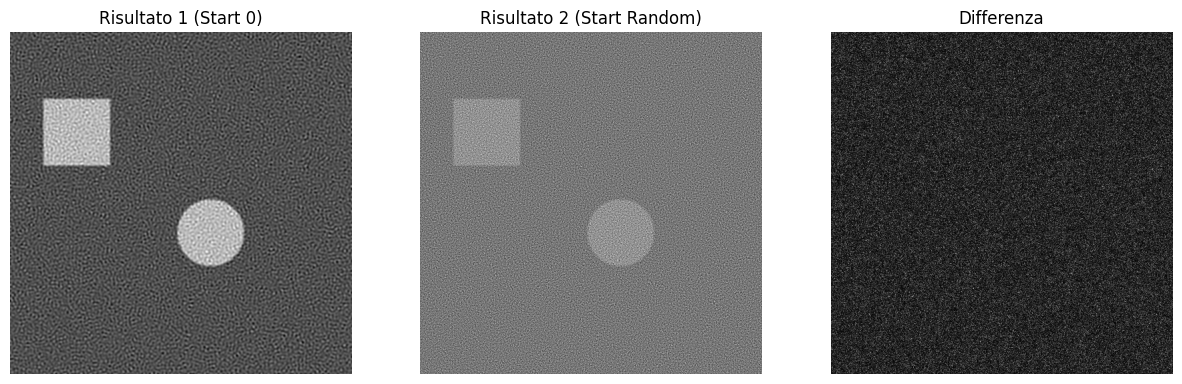

In [45]:
res1_clean, _ = solver.solve(y_noisy_clean, iterations=50, x_init=np.zeros_like(y_noisy_clean), verbose=False)
rand_start_clean = np.random.normal(0, 1, y_noisy_clean.shape)
res2_clean, _ = solver.solve(y_noisy_clean, iterations=50, x_init=rand_start_clean, verbose=False)
diff_norm_clean = np.linalg.norm(res1_clean - res2_clean)

print(f"Distanza euclidea tra le due soluzioni dopo 50 iterazioni: {diff_norm_clean:.4f}")

show_images([res1_clean, res2_clean, np.abs(res1_clean - res2_clean)],
            ["Risultato 1 (Start 0)", "Risultato 2 (Start Random)", "Differenza"])

### 4.8 Analisi della Qualità della Ricostruzione

In [46]:
# Calcolare le metriche di qualità
def compute_metrics(reconstructed, original):
    """Calcola MSE e PSNR tra immagine ricostruita e originale."""
    mse = np.mean((reconstructed - original)**2)
    max_val = np.max(original)
    psnr = 20 * np.log10(max_val / np.sqrt(mse)) if mse > 0 else np.inf
    return mse, psnr

# Metriche per i diversi metodi su immagine sintetica
methods_clean = {
    'Inverso Diretto': reconstructed_clean_noisy,
    'Wiener Filter': reconstructed_clean_regularized,
    'Landweber (50 iter)': x_rec_clean_noisy_iter
}

print("\nMetriche di Qualità Ricostruzione (Immagine Sintetica):")
print("=" * 70)
print(f"{'Metodo':<25} {'MSE':<20} {'PSNR (dB)':<20}")
print("=" * 70)

for method_name, reconstructed in methods_clean.items():
    mse, psnr = compute_metrics(reconstructed, clean_image_normalized)
    print(f"{method_name:<25} {mse:<20.8f} {psnr:<20.4f}")

print("=" * 70)



Metriche di Qualità Ricostruzione (Immagine Sintetica):
Metodo                    MSE                  PSNR (dB)           
Inverso Diretto           0.02757243           15.5952             
Wiener Filter             0.02018925           16.9488             
Landweber (50 iter)       0.04294790           13.6706             
